# Water OPPP-MSX Project — Layer 0 (v2, with confirmed working MSX API)

This version replaces the earlier placeholder Cell 7 with the **verified WNTR MSX API**, confirmed directly from the official multispecies tutorial. Sections marked `CUSTOMIZE` are where you'll swap in your own Legionella/Pseudomonas biofilm species and reactions once ready.

## Cell 1 — Mount Google Drive

In [2]:
from google.colab import drive
drive.mount('/content/drive')

import os
PROJECT_DIR = '/content/drive/MyDrive/water-oppp-msx'
os.makedirs(PROJECT_DIR, exist_ok=True)
os.chdir(PROJECT_DIR)
print('Working directory:', os.getcwd())

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Working directory: /content/drive/MyDrive/water-oppp-msx


## Cell 2 — Environment setup (rerun every session)

In [3]:
!pip install wntr numpy pandas matplotlib shap xgboost lightgbm scikit-learn SALib -q
print('Environment ready. If this is a fresh session, restart runtime now (Runtime > Restart session), then skip this cell and continue below.')

Environment ready. If this is a fresh session, restart runtime now (Runtime > Restart session), then skip this cell and continue below.


## Cell 3 — Verify installation

In [4]:
import numpy, pandas, matplotlib, sklearn, shap
import wntr
print('WNTR version:', wntr.__version__)
print('All core packages imported successfully.')

WNTR version: 1.5.0
All core packages imported successfully.


## Cell 4 — Get the benchmark networks (WNTR examples repo)

In [5]:
if not os.path.exists('wntr_source'):
    !git clone --depth 1 https://github.com/USEPA/WNTR.git wntr_source -q
    print('WNTR examples cloned.')
else:
    print('wntr_source already exists — skipping clone.')

NET3_PATH = 'wntr_source/examples/networks/Net3.inp'
print('Net3 present:', os.path.exists(NET3_PATH))

wntr_source already exists — skipping clone.
Net3 present: True


## Cell 5 — Hydraulics-only test run

In [6]:
import wntr

wn = wntr.network.WaterNetworkModel(NET3_PATH)
sim = wntr.sim.EpanetSimulator(wn)
results = sim.run_sim()
print('Simulation ran successfully.')
print(results.node['pressure'].head())

Simulation ran successfully.
name          10         15         20         35        40        50  \
0      -0.450070  28.593657   8.839204  40.612469  3.992880  7.162800   
3600   28.253721  28.887156   9.099179  41.513771  4.191203  6.752899   
7200   28.764309  30.003231   9.450786  42.429108  4.620553  6.369764   
10800  28.871420  30.415579   9.869709  42.817181  5.158957  6.534997   
14400  29.659281  31.970745  10.284730  44.297886  5.665973  6.740044   

name          60        601         61        101  ...        267        269  \
0      63.706444  92.187874  92.187874  31.553928  ...  38.151543  44.650841   
3600   63.751488  92.490318  92.490318  39.867870  ...  39.722370  45.767307   
7200   63.793495  92.773643  92.773643  41.517067  ...  40.730850  46.730705   
10800  63.813141  92.906601  92.906601  41.862659  ...  41.116528  47.115646   
14400  63.877914  93.346977  93.346977  44.400757  ...  42.755901  48.670105   

name         271        273        275  River  Lake

## Cell 6 — Network visualization

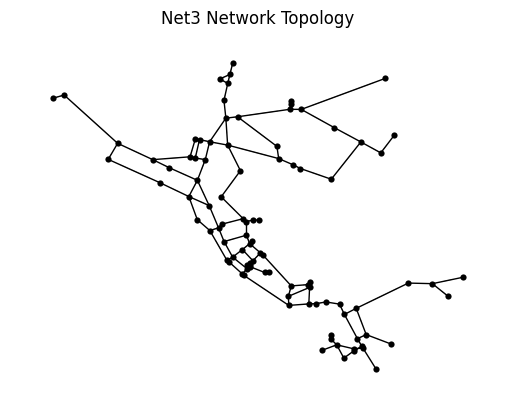

In [7]:
import matplotlib.pyplot as plt
wntr.graphics.plot_network(wn, title='Net3 Network Topology')
plt.show()

## Cell 7 — MSX imports (confirmed from official tutorial)

**Important:** the water quality parameter must be reset to `"NONE"` before attaching MSX, to avoid conflicts with EPANET's built-in single-species quality engine.

In [8]:
from pprint import pprint
import json
from wntr.msx.elements import InitialQuality
from wntr.library.msx import MsxLibrary
from wntr.msx import io as msxio
print('MSX imports ready.')

MSX imports ready.


## Cell 8 — Baseline replication: two-source chlorine decay (from EPANET-MSX user manual)

This exactly replicates the confirmed working tutorial example — run this once, unmodified, to prove the MSX pipeline itself works before introducing your own biology. `T1` is a source tracer; `CL2` is free chlorine decaying at different rates depending on which source's water it's in.

In [9]:
# New MSX model: NOM-dependent chlorine decay (replaces the T1 tracer toy example)
wn3 = wntr.network.WaterNetworkModel(NET3_PATH)
wn3.options.quality.parameter = 'NONE'
wn3.add_msx_model()
wn3.msx.title = 'NOM-dependent Multisource Chlorine Decay'

wn3.msx.options.area_units = 'FT2'
wn3.msx.options.rate_units = 'DAY'
wn3.msx.options.timestep = 300

# Species: real organic matter from each source, plus chlorine
NOMA = wn3.msx.add_species('NOMA', 'bulk', units='MG', note='NOM from Source A (Lake)')
NOMB = wn3.msx.add_species('NOMB', 'bulk', units='MG', note='NOM from Source B (River)')
CL2  = wn3.msx.add_species('CL2', 'bulk', units='MG', note='Free Chlorine')

# Coefficients — placeholder values, replace with literature-cited constants before final runs
KbA = wn3.msx.add_constant('KbA', 0.5, units='1/day')  # chlorine decay rate via NOM-A
KbB = wn3.msx.add_constant('KbB', 0.1, units='1/day')  # chlorine decay rate via NOM-B

# Reactions — chlorine consumption depends on local NOM concentration from each source
rxn_NOMA = wn3.msx.add_reaction('NOMA', 'pipe', 'rate', '-KbA*NOMA*CL2')
rxn_NOMB = wn3.msx.add_reaction('NOMB', 'pipe', 'rate', '-KbB*NOMB*CL2')
rxn_CL2  = wn3.msx.add_reaction('CL2', 'pipe', 'rate', '-KbA*NOMA*CL2 - KbB*NOMB*CL2')

# Tank reactions (addressing the earlier warning properly this time)
wn3.msx.add_reaction('NOMA', 'tank', 'rate', '-KbA*NOMA*CL2')
wn3.msx.add_reaction('NOMB', 'tank', 'rate', '-KbB*NOMB*CL2')
wn3.msx.add_reaction('CL2', 'tank', 'rate', '-KbA*NOMA*CL2 - KbB*NOMB*CL2')

print(repr(rxn_CL2))

Reaction(species_name='CL2', expression_type='RATE', expression='-KbA*NOMA*CL2 - KbB*NOMB*CL2')


In [10]:
# Initial quality: each source loaded with its own organic matter profile + starting chlorine
net_data = wn3.msx.network_data
net_data.initial_quality['NOMA'] = InitialQuality(node_values={'Lake': 3.0})
net_data.initial_quality['NOMB'] = InitialQuality(node_values={'River': 1.0})
net_data.initial_quality['CL2']  = InitialQuality(node_values={'Lake': 2.5, 'River': 1.5})
pprint(net_data.initial_quality)

{'CL2': InitialQuality(global_value=0.0, node_values=<2 entries>, link_values=<0 entries>),
 'NOMA': InitialQuality(global_value=0.0, node_values=<1 entries>, link_values=<0 entries>),
 'NOMB': InitialQuality(global_value=0.0, node_values=<1 entries>, link_values=<0 entries>)}


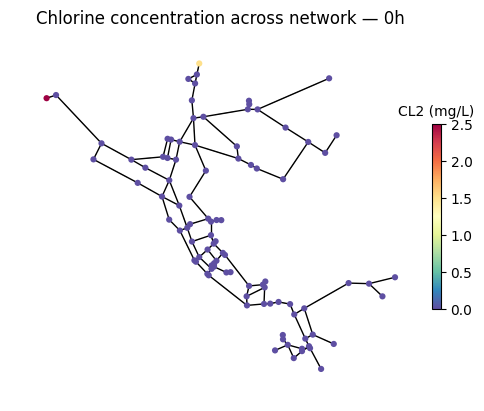

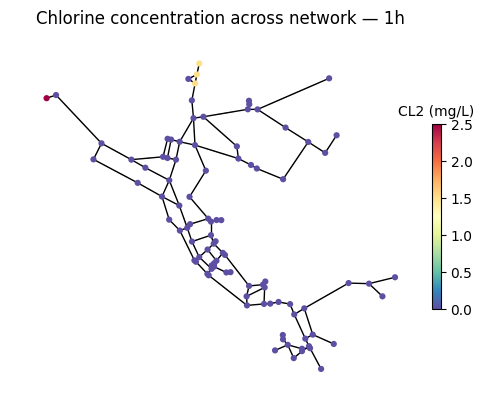

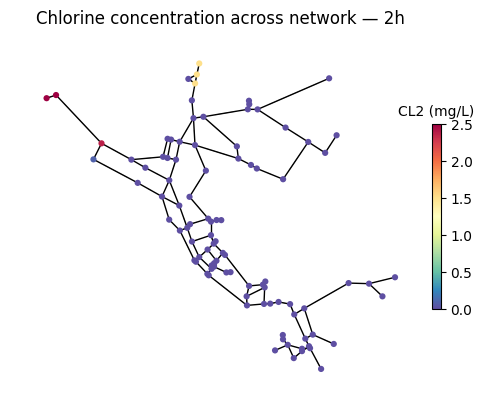

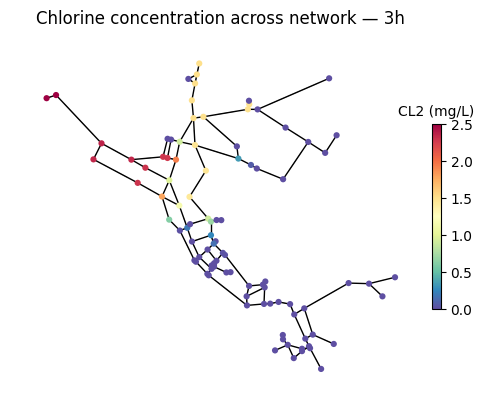

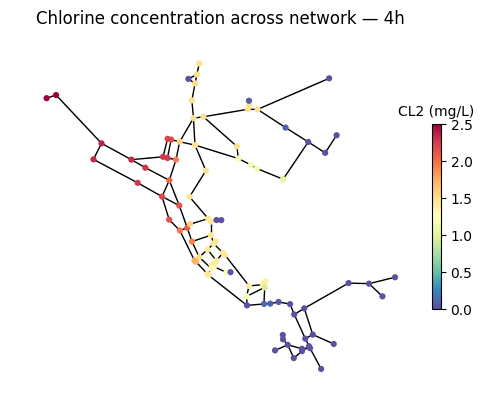

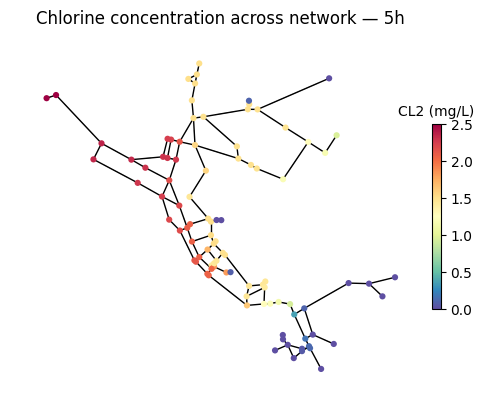

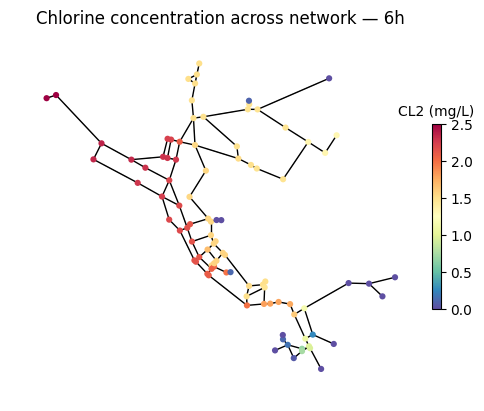

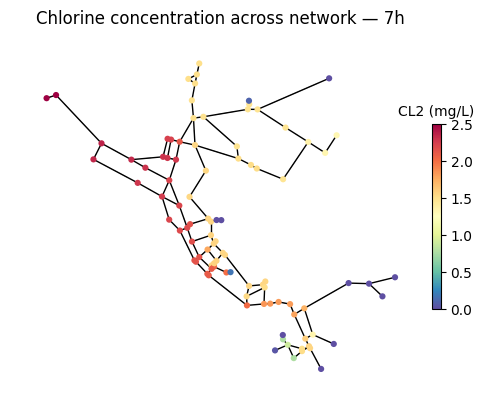

In [11]:
import wntr
import matplotlib.pyplot as plt

# <-- ADD THESE TWO LINES BACK
sim3 = wntr.sim.EpanetSimulator(wn3)
res3 = sim3.run_sim()

for plot_hr in [0,1,2,3,4,5,6,7]:
    wntr.graphics.plot_network(
        wn3,
        node_attribute=res3.node['CL2'].loc[3600 * plot_hr, :],
        title=f'Chlorine concentration across network — {plot_hr}h',
        node_colorbar_label='CL2 (mg/L)'
    )
    plt.show()

## Cell 9 — Plot chlorine residual at a node (baseline sanity check)

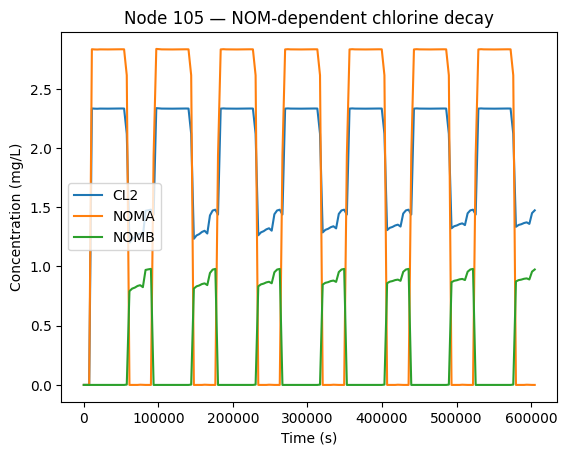

In [12]:
junction_name = '105'
res3.node['CL2'][junction_name].plot(label='CL2')
res3.node['NOMA'][junction_name].plot(label='NOMA')
res3.node['NOMB'][junction_name].plot(label='NOMB')
plt.title(f'Node {junction_name} — NOM-dependent chlorine decay')
plt.xlabel('Time (s)'); plt.ylabel('Concentration (mg/L)')
plt.legend()
plt.show()

# Cell 10 Biology block


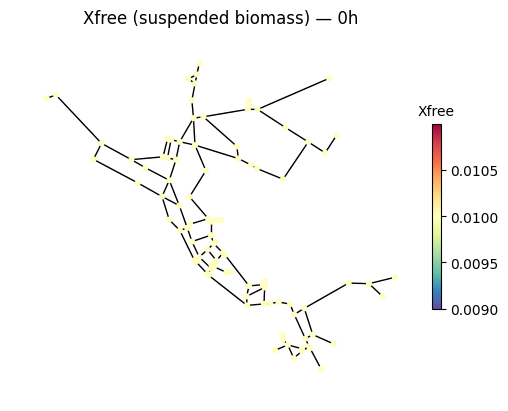

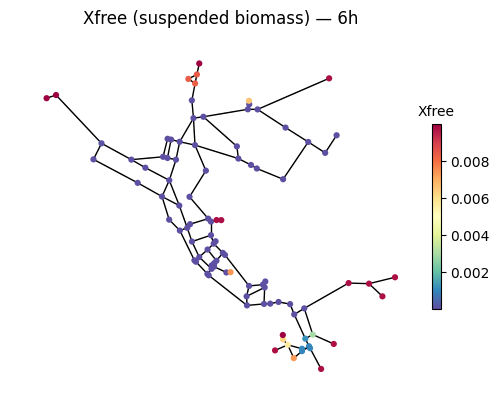

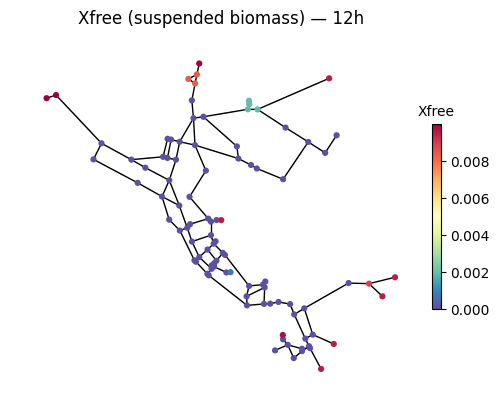

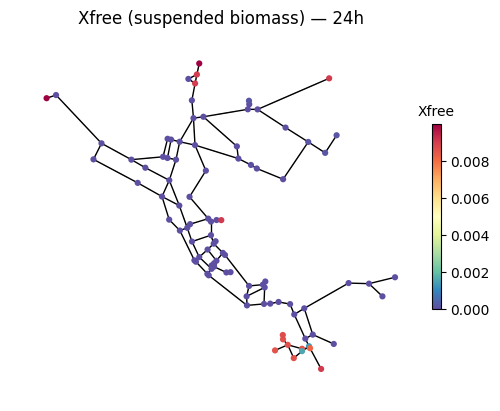

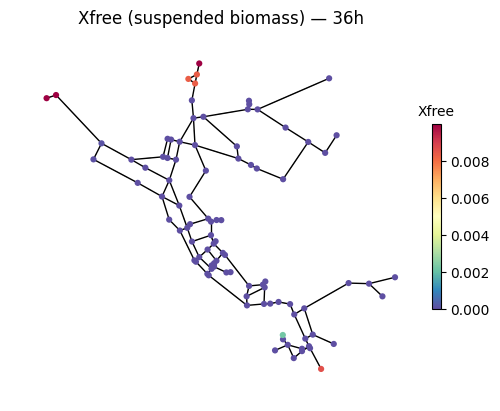

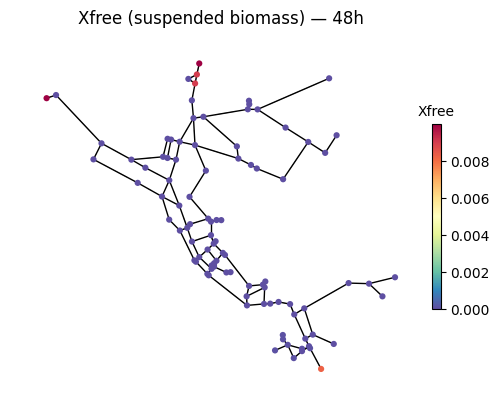

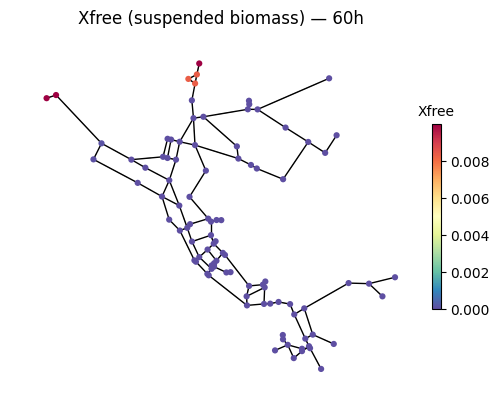

In [13]:
# Extend existing wn3.msx (NOMA, NOMB, CL2 already defined) with OPPP biology
if 'Xfree' not in wn3.msx.reaction_system:
    Xfree = wn3.msx.add_species('Xfree', 'bulk', units='MG', note='Suspended Legionella/Pseudomonas')
    Xwall = wn3.msx.add_species('Xwall', 'wall', units='MG', note='Biofilm-associated Legionella/Pseudomonas')

    umax   = wn3.msx.add_constant('umax',   2.0,  units='1/day')
    Ks     = wn3.msx.add_constant('Ks',     0.1,  units='MG')
    Kinact = wn3.msx.add_constant('Kinact', 50.0, units='1/day')
    Kdep   = wn3.msx.add_constant('Kdep',   0.1,  units='1/day')
    Kdet   = wn3.msx.add_constant('Kdet',   0.05, units='1/day')
    Y      = wn3.msx.add_constant('Y',      0.5,  units='dimensionless')

    wn3.msx.add_reaction('Xfree', 'pipe', 'rate',
        'umax*(NOMA+NOMB)/(Ks+NOMA+NOMB)*Xfree - Kinact*CL2*Xfree - Kdep*Xfree + Kdet*Xwall*Av')
    wn3.msx.add_reaction('Xwall', 'pipe', 'rate',
        'Y*Kdep*Xfree/Av - Kdet*Xwall - Kinact*CL2*Xwall')
    wn3.msx.add_reaction('Xfree', 'tank', 'rate',
        'umax*(NOMA+NOMB)/(Ks+NOMA+NOMB)*Xfree - Kinact*CL2*Xfree')

    net_data = wn3.msx.network_data
    net_data.initial_quality['Xfree'] = InitialQuality(global_value=0.01)
else:
    print('Xfree/Xwall already in wn3.msx — skipping re-add.')

sim3 = wntr.sim.EpanetSimulator(wn3)
res3 = sim3.run_sim()

for plot_hr in [0,6,12,24,36,48,60]:
    wntr.graphics.plot_network(wn3, node_attribute=res3.node['Xfree'].loc[3600*plot_hr, :],
        title=f'Xfree (suspended biomass) — {plot_hr}h', node_colorbar_label='Xfree')
    plt.show()

# Cell 11 node-level Xfree/Xwall time series

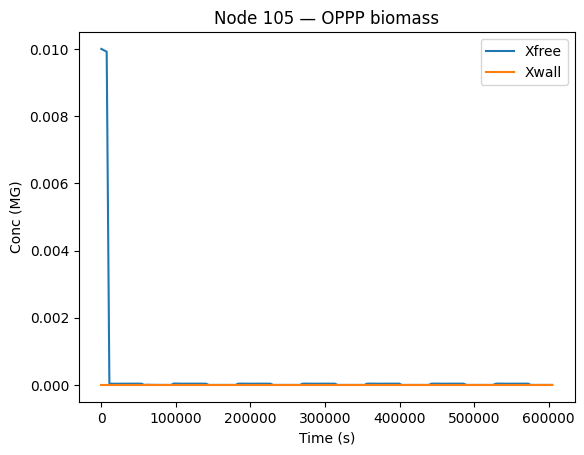

In [14]:
res3.node['Xfree'][junction_name].plot(label='Xfree')
res3.node['Xwall'][junction_name].plot(label='Xwall')
plt.title(f'Node {junction_name} — OPPP biomass'); plt.xlabel('Time (s)'); plt.ylabel('Conc (MG)')
plt.legend(); plt.show()

In [15]:
for src in ['Lake', 'River']:
    print(src, wn3.get_node(src).node_type, wn3.get_links_for_node(src))

Lake Reservoir ['10']
River Reservoir ['60']


# Sobol sampling

In [16]:
from SALib.sample import sobol
from SALib.analyze import sobol as sobol_analyze

problem = {'num_vars': 6, 'names': ['umax','Ks','Kinact','Kdep','Kdet','Y'],
           'bounds': [[1.0,4.0],[0.01,0.5],[0.5,5.0],[0.01,0.5],[0.01,0.3],[0.2,0.8]]}
param_values = sobol.sample(problem, N=8)
print('Sobol samples generated:', param_values.shape)

Sobol samples generated: (112, 6)


In [17]:
wn3.options.time.duration = 24 * 3600
print('wn3 duration set to:', wn3.options.time.duration, 'seconds')

wn3 duration set to: 86400.0 seconds


In [18]:
import numpy as np, time
qoi = []
t0 = time.time()
for i, row in enumerate(param_values):
    for name, val in zip(problem['names'], row):
        wn3.msx.reaction_system.constants[name].value = val
    try:
        r = wntr.sim.EpanetSimulator(wn3).run_sim()
        qoi.append(r.node['Xfree'][junction_name].iloc[-1])
    except Exception as e:
        print(f'Run {i} failed ({e}) — closing MSX handle, recording NaN')
        try:
            _tmp = wntr.epanet.msx.MSXepanet('temp.inp','temp.msx-rpt','temp.bin','temp.msx')
            _tmp.MSXclose()
        except Exception:
            pass
        qoi.append(np.nan)
    if (i+1) % 50 == 0:
        elapsed = time.time() - t0
        print(f'{i+1}/{len(param_values)} done, {elapsed:.1f}s elapsed, ~{elapsed/(i+1)*len(param_values):.0f}s est total')
qoi = np.array(qoi)
print(f'Batch runs complete: {qoi.shape}, total time {time.time()-t0:.1f}s')
print('NaN count:', np.isnan(qoi).sum(), '/ std (excluding NaN):', np.nanstd(qoi))

50/112 done, 269.4s elapsed, ~603s est total
100/112 done, 538.3s elapsed, ~603s est total
Batch runs complete: (112,), total time 600.4s
NaN count: 0 / std (excluding NaN): 0.0023646862


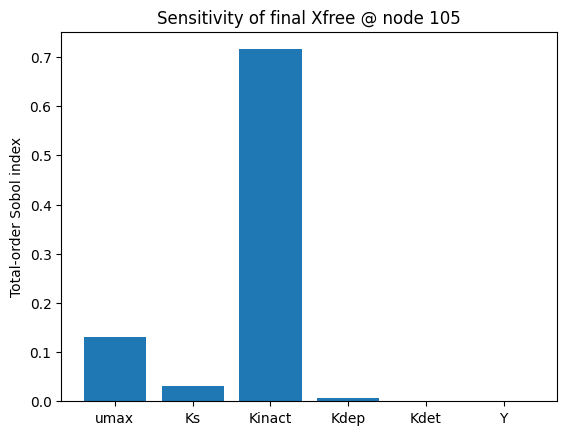

{'S1': array([-0.135,  0.113,  0.478,  0.074,  0.002, -0.001]), 'S1_conf': array([0.405, 0.133, 0.829, 0.073, 0.002, 0.002]), 'ST': array([1.300e-01, 3.013e-02, 7.156e-01, 6.265e-03, 7.225e-06, 3.714e-06]), 'ST_conf': array([1.366e-01, 3.642e-02, 7.335e-01, 7.813e-03, 1.109e-05, 5.497e-06]), 'S2': array([[   nan,  0.315,  0.542,  0.316,  0.301,  0.301],
       [   nan,    nan, -0.165, -0.176, -0.168, -0.168],
       [   nan,    nan,    nan,  0.305,  0.394,  0.394],
       [   nan,    nan,    nan,    nan, -0.046, -0.045],
       [   nan,    nan,    nan,    nan,    nan, -0.002],
       [   nan,    nan,    nan,    nan,    nan,    nan]]), 'S2_conf': array([[  nan, 0.371, 0.742, 0.367, 0.351, 0.35 ],
       [  nan,   nan, 0.166, 0.152, 0.148, 0.148],
       [  nan,   nan,   nan, 0.801, 0.698, 0.697],
       [  nan,   nan,   nan,   nan, 0.064, 0.063],
       [  nan,   nan,   nan,   nan,   nan, 0.003],
       [  nan,   nan,   nan,   nan,   nan,   nan]])}


In [19]:
Si = sobol_analyze.analyze(problem, qoi)
plt.bar(problem['names'], Si['ST'])
plt.ylabel('Total-order Sobol index'); plt.title(f'Sensitivity of final Xfree @ node {junction_name}')
plt.show()
print(Si)

## Cell — Export to raw `.msx` text (see the actual corrected syntax)

This confirms the real section headers (`[TERMS]`, `[PIPES]`, not the invalid `[REACTIONS]`/`[EXPRESSIONS]` used earlier) by writing out what WNTR actually generates.

In [20]:
msxio.write_msxfile(wn3.msx, 'oppp_full_model.msx')
with open('oppp_full_model.msx', 'r') as f:
    print(f.read())

; WNTR-reactions MSX file generated 2026-07-12 14:27:29.527675

[TITLE]
  NOM-dependent Multisource Chlorine Decay

[OPTIONS]
  AREA_UNITS  FT2
  RATE_UNITS  DAY
  SOLVER      RK5
  COUPLING    NONE
  TIMESTEP    300
  ATOL        0.0001
  RTOL        0.0001
  COMPILER    NONE
  SEGMENTS    5000
  PECLET      1000

[SPECIES]
  BULK         NOMA     MG       ; NOM from Source A (Lake)
  BULK         NOMB     MG       ; NOM from Source B (River)
  BULK         CL2      MG       ; Free Chlorine
  BULK         Xfree    MG       ; Suspended Legionella/Pseudomonas
  WALL         Xwall    MG       ; Biofilm-associated Legionella/Pseudomonas

[COEFFICIENTS]
  CONSTANT     KbA      0.5             
  CONSTANT     KbB      0.1             
  CONSTANT     umax     2.973120075650513
  CONSTANT     Ks       0.1780525110848248
  CONSTANT     Kinact   2.625667835585773
  CONSTANT     Kdep     0.05909618886187673
  CONSTANT     Kdet     0.1841626895777881
  CONSTANT     Y        0.7149023206904532

[T